In [1]:
#Adding current repo to path because it wasn't there
import sys
import os
print(sys.path)
sys.path.append(os.path.abspath('/home/av_linux/AIRXD-CNN'))

['/root/miniconda3/envs/airxd_cnn_fresh_pyfai/lib/python311.zip', '/root/miniconda3/envs/airxd_cnn_fresh_pyfai/lib/python3.11', '/root/miniconda3/envs/airxd_cnn_fresh_pyfai/lib/python3.11/lib-dynload', '', '/root/miniconda3/envs/airxd_cnn_fresh_pyfai/lib/python3.11/site-packages', '/home/av_linux/AIRXD-ML-PUB']


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from c_algorithms.azimuthal_processing import azimuthal_binning

In [10]:
def create_sawtooth_ring(size=1000, ring_radius=200, width=5, amplitude=100):
    """
    Create a synthetic test case with a sawtooth pattern embedded in an azimuthal ring.
    This creates an asymmetric pattern that should be preserved when extracted.
    """
    # Create 2D grid
    y, x = np.indices((size, size))
    center_y, center_x = size // 2, size // 2
    
    # Calculate distance from center and angle
    r = np.sqrt((x - center_x)**2 + (y - center_y)**2).astype(np.float32)
    phi = np.arctan2(y - center_y, x - center_x)
    # Adjust phi to [0, 2π) range for convenience
    phi = np.mod(phi, 2*np.pi)
    
    # Create mask for the ring
    ring_mask = np.abs(r - ring_radius) < width
    
    # Initialize image array
    image = np.zeros((size, size), dtype=np.float32)
    
    # Create a sawtooth pattern along the azimuthal angle
    # This creates a pattern that increases from 0 to amplitude as we go around clockwise
    # The pattern repeats 3 times around the full circle
    num_repeats = 3
    sawtooth_pattern = np.mod(phi * num_repeats / (2*np.pi), 1.0) * amplitude
    
    # Apply the sawtooth pattern to the ring
    image[ring_mask] = sawtooth_pattern[ring_mask]
    
    # Add a small amount of noise
    image += np.random.normal(0, 2, (size, size)).astype(np.float32)
    
    return image, r, phi, sawtooth_pattern



In [6]:
image.shape, two_theta.shape, theta_val.shape

((1000, 1000), (1000, 1000), (301,))

In [11]:
# Create test data with sawtooth pattern
size = 1000
print("Creating test data with sawtooth pattern...")
image, two_theta, phi, original_pattern = create_sawtooth_ring(size=size)

# Create a mask (False = include pixel, True = exclude pixel)
# For this test, we'll include all pixels
mask = np.zeros((size, size), dtype=bool)

# Define theta value bins for 2-theta values
num_bins = 300
theta_val = np.linspace(0, np.max(two_theta), num_bins + 1).astype(np.float32)

# Extract the azimuthal rings using our improved algorithm
print("Extracting azimuthal rings...")
binned_arrays, global_mean = azimuthal_binning(image, two_theta, theta_val, mask)

# Find which bin contains our test ring
# The ring radius was set to 200, so find the bin that covers that value
target_radius = 200
target_bin = np.argmin(np.abs((theta_val[:-1] + theta_val[1:]) / 2 - target_radius))
print(f"Target ring is in bin {target_bin}")

# Extract the 1D array for the target bin
extracted_pattern = np.array(binned_arrays[target_bin])

Creating test data with sawtooth pattern...
Extracting azimuthal rings...
Target ring is in bin 84


In [12]:
# For visualization, also extract the raw pattern directly from the image
# This gives us a ground truth to compare against
def extract_ground_truth_pattern(image, size, ring_radius, width):
    # Create coordinates for extracting points directly at the correct radius
    center = size // 2
    num_points = 1000
    angles = np.linspace(0, 2*np.pi, num_points, endpoint=False)
    
    x_coords = center + ring_radius * np.cos(angles)
    y_coords = center + ring_radius * np.sin(angles)
    
    # Convert to integer indices
    x_coords = np.clip(x_coords.astype(int), 0, size-1)
    y_coords = np.clip(y_coords.astype(int), 0, size-1)
    
    # Extract values directly from the image
    direct_pattern = image[y_coords, x_coords]
    return direct_pattern, angles



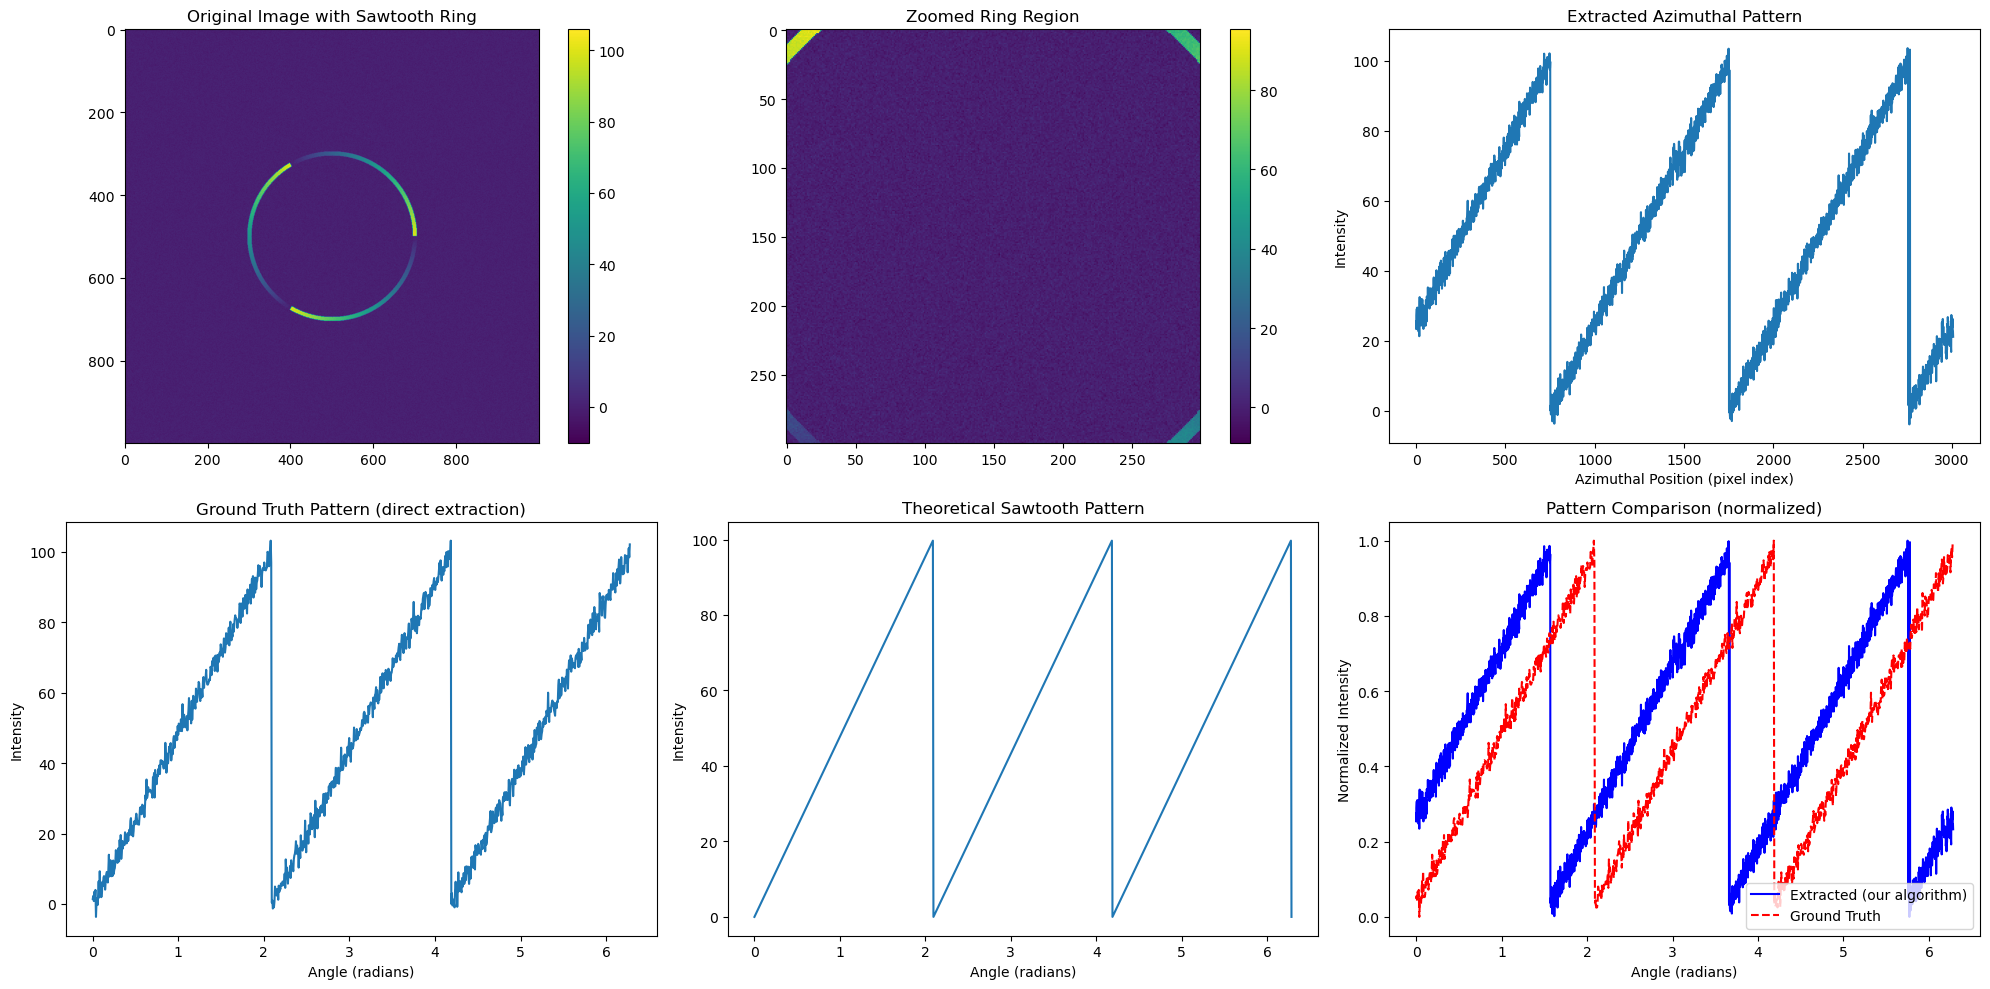

Correlation between extracted and ground truth patterns: -0.1233
p-value: 0.00009315
Number of sign changes in extracted pattern derivative: 1988
Number of sign changes in ground truth pattern derivative: 648


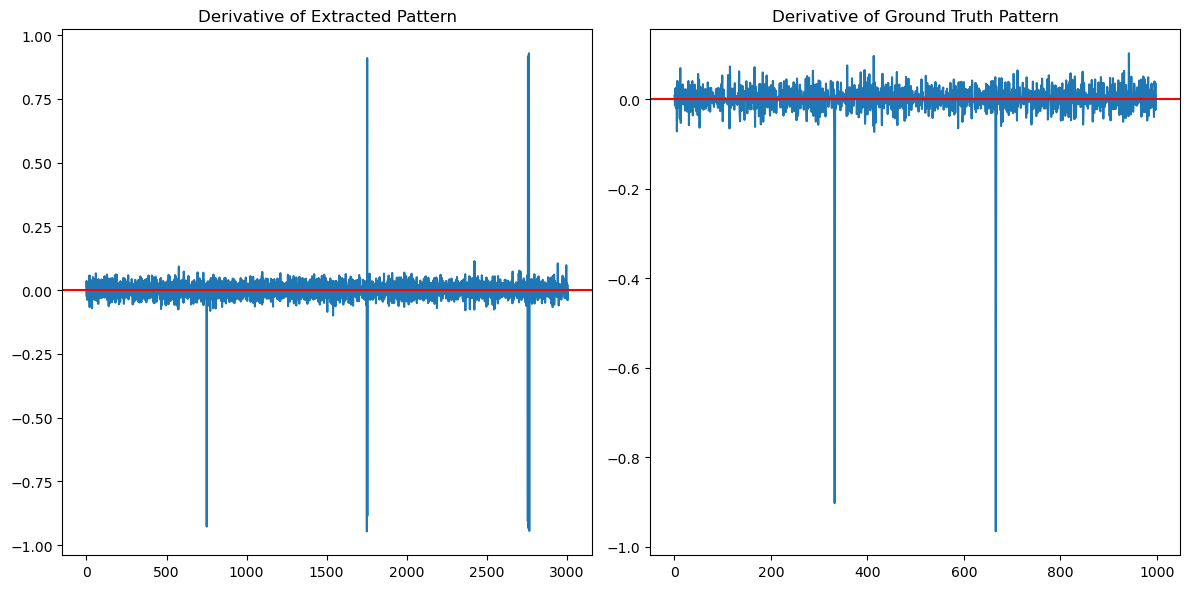

In [13]:
# Extract ground truth pattern
direct_pattern, angles = extract_ground_truth_pattern(image, size, 200, 20)

# Visualize the results
plt.figure(figsize=(20, 10))

# Original image
plt.subplot(2, 3, 1)
plt.imshow(image, cmap='viridis')
plt.title('Original Image with Sawtooth Ring')
plt.colorbar()

# Zoom in on the ring
plt.subplot(2, 3, 2)
center = size // 2
zoom_size = 300
plt.imshow(image[center-zoom_size//2:center+zoom_size//2, center-zoom_size//2:center+zoom_size//2], cmap='viridis')
plt.title('Zoomed Ring Region')
plt.colorbar()

# Plot the extracted 1D pattern from our algorithm
plt.subplot(2, 3, 3)
plt.plot(extracted_pattern)
plt.title('Extracted Azimuthal Pattern')
plt.xlabel('Azimuthal Position (pixel index)')
plt.ylabel('Intensity')

# Plot the ground truth sawtooth pattern
plt.subplot(2, 3, 4)
plt.plot(angles, direct_pattern)
plt.title('Ground Truth Pattern (direct extraction)')
plt.xlabel('Angle (radians)')
plt.ylabel('Intensity')

# Plot original sawtooth pattern formula
plt.subplot(2, 3, 5)
num_repeats = 3
plot_angles = np.linspace(0, 2*np.pi, 1000)
theoretical_pattern = np.mod(plot_angles * num_repeats / (2*np.pi), 1.0) * 100
plt.plot(plot_angles, theoretical_pattern)
plt.title('Theoretical Sawtooth Pattern')
plt.xlabel('Angle (radians)')
plt.ylabel('Intensity')

# Normalize and overlay both patterns for comparison
plt.subplot(2, 3, 6)
# Normalize both patterns to [0, 1] for comparison
norm_extracted = (extracted_pattern - np.min(extracted_pattern)) / (np.max(extracted_pattern) - np.min(extracted_pattern))
norm_direct = (direct_pattern - np.min(direct_pattern)) / (np.max(direct_pattern) - np.min(direct_pattern))

# Normalize extracted pattern length to match direct pattern
x_extracted = np.linspace(0, 2*np.pi, len(norm_extracted))
x_direct = angles

plt.plot(x_extracted, norm_extracted, 'b-', label='Extracted (our algorithm)')
plt.plot(x_direct, norm_direct, 'r--', label='Ground Truth')
plt.title('Pattern Comparison (normalized)')
plt.xlabel('Angle (radians)')
plt.ylabel('Normalized Intensity')
plt.legend()

plt.tight_layout()
plt.savefig('sawtooth_test_results.png')
plt.show()

# Calculate correlation between extracted and ground truth patterns
# Resample to the same length first
from scipy.interpolate import interp1d

x_new = np.linspace(0, 1, 1000)
f_extracted = interp1d(np.linspace(0, 1, len(norm_extracted)), norm_extracted)
f_direct = interp1d(np.linspace(0, 1, len(norm_direct)), norm_direct)

resampled_extracted = f_extracted(x_new)
resampled_direct = f_direct(x_new)

from scipy.stats import pearsonr
correlation, p_value = pearsonr(resampled_extracted, resampled_direct)

print(f"Correlation between extracted and ground truth patterns: {correlation:.4f}")
print(f"p-value: {p_value:.8f}")

# Check if the sawtooth pattern's rising edges are preserved
# by calculating the first derivative
extracted_derivative = np.diff(norm_extracted)
direct_derivative = np.diff(norm_direct)

# Count sign changes in derivatives (should match for both if pattern is preserved)
extracted_sign_changes = np.sum(np.abs(np.diff(np.sign(extracted_derivative))) > 0)
direct_sign_changes = np.sum(np.abs(np.diff(np.sign(direct_derivative))) > 0)

print(f"Number of sign changes in extracted pattern derivative: {extracted_sign_changes}")
print(f"Number of sign changes in ground truth pattern derivative: {direct_sign_changes}")

# Plot the derivatives for visual comparison
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(extracted_derivative)
plt.title('Derivative of Extracted Pattern')
plt.axhline(y=0, color='r', linestyle='-')

plt.subplot(1, 2, 2)
plt.plot(direct_derivative)
plt.title('Derivative of Ground Truth Pattern')
plt.axhline(y=0, color='r', linestyle='-')

plt.tight_layout()
plt.savefig('derivative_comparison.png')
plt.show()